In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

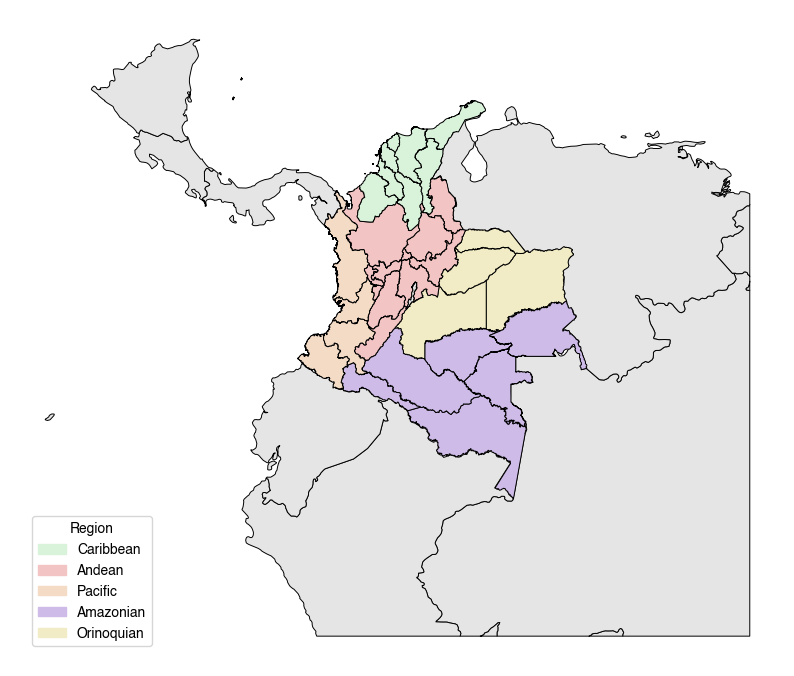

In [47]:
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Helvetica'

# Load world data and Colombia boundaries
world = gpd.read_file('/DENV/2024/world-administrative-boundaries.geojson')
colombia_boundaries = gpd.read_file("/DENV/2024/geoBoundaries-COL-ADM1.geojson")

world_inset = world.cx[-120:-30, -60:90]

# Filter for countries in Latin America & Caribbean
latin_america_countries = ['Brazil', 'Ecuador', 'Peru', 'Venezuela', 'Bolivia', 'Panama', 'Costa Rica', 'Nicaragua', 'Guyana', 'Suriname', 'French Guiana']
latin_america = world[world['name'].isin(latin_america_countries)]

# Define regions
caribbean = ['Archipiélago de San Andrés, Providencia y Santa Catalina','Atlántico', 'Bolívar', 'Magdalena', 'La Guajira', 'Cesar', 'Córdoba', 'Sucre']
andean = ['Cundinamarca', 'Caldas', 'Tolima','Antioquia', 'Boyacá', 'Huila', 'Santander', 'Norte de Santander', 'Quindío', 'Risaralda','Bogotá D.C.']
pacific = ['Valle del Cauca','Chocó','Cauca','Nariño']
amazonian = ['Amazonas', 'Caquetá', 'Guainía', 'Guaviare', 'Putumayo','Vaupés']
orinoquia = ['Arauca', 'Casanare', 'Meta', 'Vichada']

# Create palette
palette = {
    'Caribbean': '#d9f2da',
    'Andean': '#f2c4c3',
    'Pacific': '#f3dbc5',
    'Amazonian': '#cebbe8',
    'Orinoquian': '#f1ecc5',
    'country_level': '#e5e5e5'
}

# Assign regions to Colombia boundaries
def assign_region(row):
    if row['shapeName'] in caribbean:
        return 'Caribbean'
    elif row['shapeName'] in andean:
        return 'Andean'
    elif row['shapeName'] in pacific:
        return 'Pacific'
    elif row['shapeName'] in amazonian:
        return 'Amazonian'
    elif row['shapeName'] in orinoquia:
        return 'Orinoquian'
    else:
        return 'country_level'

colombia_boundaries['region'] = colombia_boundaries.apply(assign_region, axis=1)

from shapely.geometry import box
import matplotlib.pyplot as plt
import geopandas as gpd

# Define the bounding box coordinates
minx, miny = -90, -10
maxx, maxy = -60, 20

# Create the bounding box
bbox = box(minx, miny, maxx, maxy)

# Convert the bounding box to a GeoDataFrame
bbox_gdf = gpd.GeoDataFrame(gpd.GeoSeries(bbox), columns=['geometry'], crs="EPSG:4326")

# Clip the Latin America map using the bounding box
latin_america_clipped = gpd.clip(latin_america, bbox_gdf)

import matplotlib.patches as mpatches

# Create a color mapping from the palette
colombia_boundaries['color'] = colombia_boundaries['region'].map(palette)

# Plot the clipped map with Colombia's ADM1 boundaries
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the clipped Latin America map
latin_america_clipped.plot(ax=ax, color=palette['country_level'], linewidth=0.7, edgecolor='black')

# Overlay Colombia with ADM1 boundaries and regions
colombia_boundaries.plot(ax=ax, color=colombia_boundaries['color'], linewidth=0.7, edgecolor='black')

# Create legend patches
legend_patches = [mpatches.Patch(color=color, label=region) for region, color in palette.items() if region != 'country_level']

# Add legend to the plot
ax.legend(handles=legend_patches, title="Region", loc='lower left', bbox_to_anchor=(0.02, 0.02), frameon=True)


# Set title and remove axes
plt.axis('off')

# Add inset map showing the full South America

# Highlight the bounding box on the inset map


resolutionValue = 1200
plt.savefig('/DENV/2024/southAmericanMap.jpeg', dpi=resolutionValue, bbox_inches='tight', format='jpeg')


plt.show()